# El-Nino -- can the Pacific Ocean predict the stock market?
### Does El Nino / La Nina move equities or commodities? Tested honestly, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Busted%3F: Yes](https://img.shields.io/badge/Busted%3F-Yes-8b949e?style=flat-square)

Every couple of years a forecaster declares an **El Nino** (a warm Pacific) or a **La Nina** (a cold one), and the market commentary follows: droughts will spike crop and energy prices, warm winters will boost the economy, *El Nino summers are bullish for stocks*. The ocean clearly moves the weather. The question this notebook asks is narrower and harder: does the ocean move **prices** -- after costs, after the honest baseline that stocks just drift up anyway?

> **This is the plain-language layer.** Want the Welch t, the ANOVA, the permutation distribution, and the HAC t-stat? That's **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** -- same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY, BLUE = "#c0392b", "#dab617", "#2ea44f", "#8b949e", "#2c7fb8"

from el_nino import data, strategy as st

def _have_cache(asset="equity"):
    try:
        data.fetch_real(asset=asset, lag=1, fetch=False)
        return True
    except FileNotFoundError:
        return False

HAVE_REAL = _have_cache("equity")
HAVE_OIL = _have_cache("oil")
print("Equity cache present:", HAVE_REAL, " | Oil cache present:", HAVE_OIL)

# Frozen headline numbers -- mirror of docs/results.md (as-of 2026-06-17)
R = dict(
    n=75, n_elnino=26, n_lanina=29, n_neutral=20,
    uncond_up_pct=73.3,
    mean_elnino=11.9, mean_lanina=8.8, mean_neutral=7.1, mean_all=9.4,
    gap_pct=3.2, welch_t=0.692, welch_p=0.492, hac_t=0.441,
    anova_f=0.508, anova_p=0.604, perm_p=0.480,
    gross_ann=-0.6, net_ann=-0.9, buy_hold_ann=8.1, turnover=1.0,
    lag0_gap_pct=1.95, lag0_welch_t=0.416, lag0_perm_p=0.649,
    oil_n=19, oil_n_elnino=7, oil_n_lanina=9,
    oil_gap_pct=-3.1, oil_welch_t=-0.161, oil_hac_t=-0.149,
    oil_anova_p=0.879, oil_perm_p=0.859,
    oil_mean_elnino=-2.2, oil_mean_lanina=0.9, oil_buy_hold_ann=-9.0,
    year_start=1951, year_end=2025,
)


Equity cache present: True  | Oil cache present: True


## The answer first

| Question | Answer |
|---|---|
| Do El Nino years beat La Nina years for the S&P? | **Barely, and not reliably.** El Nino years average **+11.9%**, La Nina years **+8.8%** -- a gap of **+3.2pp**, Welch t = **0.69**, permutation p = **0.48**. |
| Is that better than just owning stocks? | **No.** The market is up **73%** of years regardless of the ocean; the long-El-Nino / short-La-Nina strategy *loses* money (gross -0.6%/yr) versus +8.1%/yr buy-and-hold. |
| Does El Nino spike oil? | **No** in our sample: oil (USO) actually averaged **-2.2%** in El Nino years vs **+0.9%** in La Nina years -- the opposite of the folklore, and statistically nothing (perm p = 0.86). |
| Could you trade it? | **No.** One signal a year, ~25 observations per phase, no edge that survives shorting costs. |

> The ocean drives the weather. It does not, in any tradable way, drive the tape.

## 1 - The claim

> *"When the Pacific warms (El Nino), droughts and floods disrupt agriculture and energy, and -- depending on who you ask -- equities rally on the warm-winter stimulus. When it cools (La Nina), the opposite. You can position ahead of it because NOAA forecasts the phase months in advance."*

The honest core of this is real: ENSO genuinely shifts global weather. There is a respectable agricultural-economics literature (Brunner 2002; Cashin, Mohaddes & Raissi 2017) finding ENSO effects on commodity prices and even inflation. The leap we test is from *weather* to a *tradable equity or oil signal*.

## 2 - So what?

If a forecastable ocean state predicted next year's equity return, it would be an extraordinary free lunch: NOAA publishes ENSO probabilities openly, months ahead. Everyone could position. Markets would price it away instantly -- which is exactly why we should be suspicious that any residual edge survives.

The fun question: the weather link is genuine, so **why doesn't it show up in prices?** The answer is a lesson in the difference between a real physical effect and a tradable financial one.

## 3 - How would we even know?

Three traps to avoid:

1. **The wrong baseline.** Equities drift up ~7%/yr and rise ~73% of years. An 'El-Nino-is-bullish' rule inherits that drift for free. The right question is whether El Nino years beat the **unconditional mean**, not zero.
2. **Tiny n.** There have been ~75 ENSO years since 1950, split roughly evenly into El Nino / La Nina / Neutral -- so only ~25 observations per phase. With ~17% equity volatility, you'd need a ~7%/yr structural gap to see a significant result. We'll check whether the observed gap is anywhere near that.
3. **Many knobs.** Equity or oil? The phase the winter the return is in, or the *next* year (you can only act once the winter is over)? The +/-0.5 ONI threshold or the raw sign? Each choice is a fork; testing many inflates false discovery.

We use NOAA's ONI (the official ENSO index, hardcoded in this study's `data.py`) and join it to S&P 500 and oil calendar-year returns, with a one-year lag so the trade is actually actionable.

## 4 - The teardown -- let's actually look

**First, meet the data:** NOAA's ONI for every winter since 1950, classified into El Nino (ONI >= +0.5), La Nina (ONI <= -0.5), and Neutral.

In [2]:
oni = data.oni_table()
counts = oni['phase'].value_counts()
print('ENSO winters 1950-2024:', len(oni))
print(counts.to_string())
print()
if HAVE_REAL:
    df = data.fetch_real(asset='equity', lag=1)
    uncond = float(df['mkt_up'].mean())
    n_tot = len(df)
else:
    uncond = R['uncond_up_pct']/100
    n_tot = R['n']
print(f'S&P calendar-year up-rate (the honest baseline): {uncond:.1%} over {n_tot} years')

ENSO winters 1950-2024: 75
phase
La Nina    29
El Nino    26
Neutral    20



S&P calendar-year up-rate (the honest baseline): 73.3% over 75 years


**The big El Nino / La Nina years are unmistakable in the index** -- 1982-83, 1997-98, 2015-16 (warm); 1973-74, 1988-89, 1999-2000 (cold). But do those ocean states line up with the market?

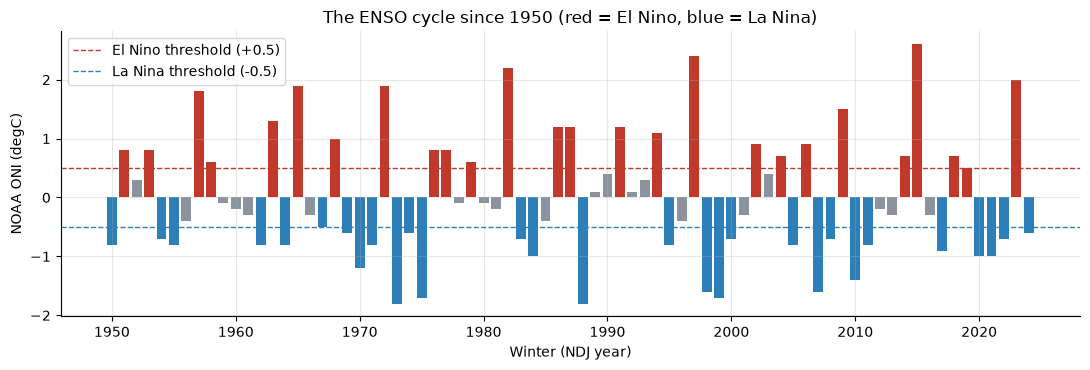

In [3]:
fig, ax = plt.subplots(figsize=(11, 3.8))
colors = oni['oni_ndj'].apply(lambda v: RED if v>=0.5 else (BLUE if v<=-0.5 else GREY))
ax.bar(oni['enso_year'], oni['oni_ndj'], color=colors, width=0.8)
ax.axhline(0.5, ls='--', c=RED, lw=1, label='El Nino threshold (+0.5)')
ax.axhline(-0.5, ls='--', c=BLUE, lw=1, label='La Nina threshold (-0.5)')
ax.set_xlabel('Winter (NDJ year)'); ax.set_ylabel('NOAA ONI (degC)')
ax.set_title('The ENSO cycle since 1950 (red = El Nino, blue = La Nina)')
ax.legend(loc='upper left'); plt.tight_layout(); plt.show()

**The phase-by-phase mean return -- the heart of the matter.**

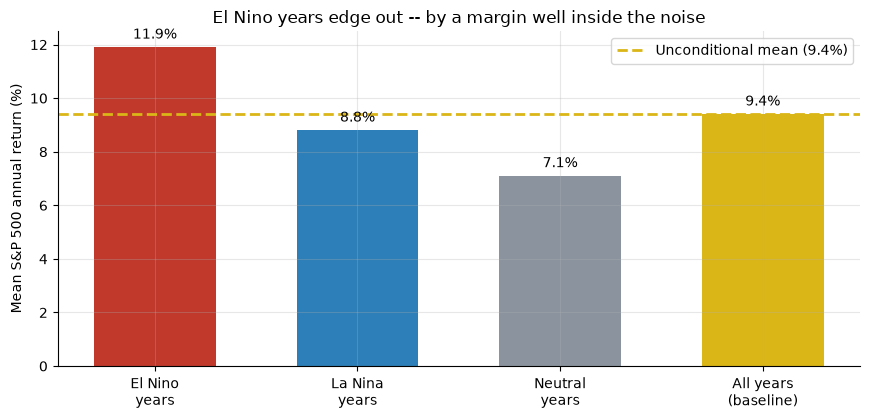

El Nino mean 11.9% vs La Nina mean 8.8% -- gap = +3.1pp


In [4]:
if HAVE_REAL:
    s = st.summarize(df, n_permutations=10_000, seed=281)
    m_el, m_la, m_ne, m_all = s['mean_elnino_pct'], s['mean_lanina_pct'], s['mean_neutral_pct'], s['mean_all_pct']
else:
    m_el, m_la, m_ne, m_all = R['mean_elnino'], R['mean_lanina'], R['mean_neutral'], R['mean_all']

fig, ax = plt.subplots(figsize=(8.8, 4.3))
bars = ax.bar(['El Nino\nyears','La Nina\nyears','Neutral\nyears','All years\n(baseline)'],
              [m_el, m_la, m_ne, m_all], color=[RED, BLUE, GREY, AMBER], width=0.6)
ax.axhline(m_all, ls='--', c=AMBER, lw=2, label=f'Unconditional mean ({m_all:.1f}%)')
ax.set_ylabel('Mean S&P 500 annual return (%)')
ax.set_title('El Nino years edge out -- by a margin well inside the noise')
for b,v in zip(bars,[m_el,m_la,m_ne,m_all]):
    ax.annotate(f'{v:.1f}%',(b.get_x()+b.get_width()/2, v+0.2), ha='center', va='bottom')
ax.legend(); plt.tight_layout(); plt.show()
print(f'El Nino mean {m_el:.1f}% vs La Nina mean {m_la:.1f}% -- gap = {m_el-m_la:+.1f}pp')

El Nino years did average more (**+11.9%** vs **+8.8%**), but the gap of **+3.2pp** sits on top of ~17% annual volatility with only ~25 observations per phase. That is exactly the size of gap you get by chance when you slice 75 noisy years three ways.

## 5 - The verdict

- **Signal -- None.** El-Nino-minus-La-Nina gap **+3.2pp**, Welch t = **0.69**, HAC t = **0.44**, one-way ANOVA p = **0.60**, permutation p = **0.48**. Nothing distinguishable from noise -- on either equities or oil.
- **Tradability -- Mirage.** The long-El-Nino / short-La-Nina strategy *underperforms* buy-and-hold (gross -0.6%/yr vs +8.1%/yr) before you even pay borrow on the shorts. There is no edge to harvest.
- **Busted.** The genuine ENSO-weather link does not survive the trip from rainfall to the tape. Oil -- where the folklore is loudest -- actually went the *wrong* way in El Nino years in our sample.

## 6 - Could you actually trade it?

The 'strategy' is: go long the S&P after an El Nino winter, short it after a La Nina winter (you wait until the winter is over -- hence the one-year lag).

In [5]:
if HAVE_REAL:
    bt = st.backtest(df, cost_bps_oneway=10.0, short_borrow_bps=50.0)
    gross, net, bah = bt['gross_ann']*100, bt['net_ann']*100, bt['buy_hold_ann']*100
else:
    gross, net, bah = R['gross_ann'], R['net_ann'], R['buy_hold_ann']

print(f'Long-El-Nino / short-La-Nina (gross):   {gross:+.1f}%/yr')
print(f'Same, net of 10bps costs + 50bps borrow: {net:+.1f}%/yr')
print(f'Buy and hold the S&P:                    {bah:+.1f}%/yr')
print()
print('Shorting the market in La Nina years (which still averaged +8.8%)')
print('is a fast way to lose money. The folklore costs you the equity premium.')

Long-El-Nino / short-La-Nina (gross):   -0.6%/yr
Same, net of 10bps costs + 50bps borrow: -0.9%/yr
Buy and hold the S&P:                    +8.1%/yr

Shorting the market in La Nina years (which still averaged +8.8%)
is a fast way to lose money. The folklore costs you the equity premium.


The strategy loses because La Nina years were *not* bear years -- they averaged **+8.8%**, and shorting them throws away the equity risk premium. There is no trade here that beats simply owning the index.

## 7 - Going further

- **The positive control:** the companion notebook plants an ENSO premium in a synthetic tape and shows the machinery *does* detect it once it is large enough. The real tape has nothing like that.
- **The weather link is real -- the price link is not.** For the genuine commodity / inflation effects, see Cashin, Mohaddes & Raissi (2017) in [docs/references.md](../docs/references.md).
- **Sibling calendar/weather mirages:** the Super Bowl Indicator ([Study 158](../../158-super-bowl/)) and the Groundhog shadow are the same shape -- a real-world curiosity that evaporates under the honest baseline.

*Think the ocean really moves the tape? Fork this, pick your asset and your phase definition, and show an El-Nino-minus-La-Nina gap with permutation p < 0.05 that survives shorting costs. That's the bar -- and it hasn't been cleared.*